# Trabajo Práctico Integrador — Entrega 2
## Ciencia de Datos 2026 | UTN FRC | 5K4 | Grupo 15

---

### Descripción de la entrega

Este notebook implementa el pipeline **ETL (Extract, Transform, Load)** completo sobre el dataset PAMAP2, correspondiente a la **Entrega 2** del TPI. Incluye:

- Carga y unificación de los 9 archivos fuente (.dat)
- Downsampling 100 Hz → 10 Hz
- Eliminación de columnas inválidas (orientación IMU)
- Exclusión de períodos transitorios (activityID = 0)
- Tratamiento de valores faltantes en heart\_rate
- Verificación y guardado del dataset limpio

---

### Integrantes — Grupo 15

| Rol            | Nombre                      | Legajo |
|----------------|----------------------------|--------|
| Product Owner  | Franco Recalde             | 94661  |
| Scrum Master   | Emilio Sadir               | 96622  |
| dev            | Rodríguez, Joaquín Ignacio | 85406  |
| dev            | Noto, Claudia Carina       | 95215  |
| dev            | Monteros, Leandro Ignacio  | 90258  |
| dev            | Ferraro, Ayelen            | 99149  |
| dev            | Chiaro, Tiziano            | 90043  |
| dev            | Bailey, Julián Eduardo     | 96032  |

---

### Dataset

**PAMAP2 Physical Activity Monitoring Dataset**  
Fuente: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/231/pamap2+physical+activity+monitoring)  
Licencia: CC BY 4.0  
Autores: A. Reiss y D. Stricker (DFKI, Alemania)

# Paso 0.0: Importación, configuración y unificación de datos
Este segmento incluye:
- Importación de librerías
- Configuración del entorno
- Definición de columnas
- Carga y unificación de archivos fuente
- Downsampling
- Visualización del impacto de estas operaciones




### Paso 0.1:Empezando con la importación de librerías:

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler


pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

print('Librerias cargadas correctamente.')

Librerias cargadas correctamente.


### Paso 0.2: Configuración del entorno

La notebook detecta automáticamente si se ejecuta en **Google Colab** o localmente.
En Colab se monta Google Drive y se asume que la carpeta del proyecto está en `MyDrive/TP_CD/`.
Ajustar `BASE_PATH` si la ubicación en Drive es diferente.

In [3]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/TP_CD')
else:
    BASE_PATH = Path('..').resolve()

DATA_PROTOCOL = BASE_PATH / 'PAMAP2_Dataset' / 'Protocol'
DATA_OPTIONAL = BASE_PATH / 'PAMAP2_Dataset' / 'Optional'
OUTPUT_PATH   = BASE_PATH / 'data' / 'processed'
FIGURES_PATH  = BASE_PATH / 'reports' / 'entrega_2' / 'figures'

OUTPUT_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

env_name = 'Google Colab' if IN_COLAB else 'Local'
print(f'Entorno:   {env_name}')
print(f'Datos en:  {DATA_PROTOCOL}')
print(f'Output en: {OUTPUT_PATH}')

Entorno:   Local
Datos en:  D:\FACU\5to\Ciencia de datos\pamap2+physical+activity+monitoring\TP_CD\PAMAP2_Dataset\Protocol
Output en: D:\FACU\5to\Ciencia de datos\pamap2+physical+activity+monitoring\TP_CD\data\processed


### Paso 0.3: Definición de columnas

El dataset PAMAP2 no incluye header en sus archivos `.dat`. Las **54 columnas** se asignan
manualmente según la documentación oficial (readme.pdf, UCI). Se identifican las
**12 columnas de orientación** (4 por IMU × 3 IMUs: hand, chest, ankle) que serán
eliminadas en el Paso 3 por ser inválidas según la documentación oficial.

In [4]:
RAW_COLUMNAS = [
    'tiempo', 'actividad_id', 'frecuencia_cardiaca',
    # IMU mano — 17 columnas
    'mano_temperatura',
    'mano_acel1_x', 'mano_acel1_y', 'mano_acel1_z',
    'mano_acel2_x', 'mano_acel2_y', 'mano_acel2_z',
    'mano_giro_x', 'mano_giro_y', 'mano_giro_z',
    'mano_magneto_x',  'mano_magneto_y',  'mano_magneto_z',
    'mano_orientacion_1', 'mano_orientacion_2', 'mano_orientacion_3', 'mano_orientacion_4',
    # IMU pecho — 17 columnas
    'pecho_temperatura',
    'pecho_acel1_x', 'pecho_acel1_y', 'pecho_acel1_z',
    'pecho_acel2_x', 'pecho_acel2_y', 'pecho_acel2_z',
    'pecho_giro_x', 'pecho_giro_y', 'pecho_giro_z',
    'pecho_magneto_x',  'pecho_magneto_y',  'pecho_magneto_z',
    'pecho_orientacion_1', 'pecho_orientacion_2', 'pecho_orientacion_3', 'pecho_orientacion_4',
    # IMU tobillo — 17 columnas
    'tobillo_temperatura',
    'tobillo_acel1_x', 'tobillo_acel1_y', 'tobillo_acel1_z',
    'tobillo_acel2_x', 'tobillo_acel2_y', 'tobillo_acel2_z',
    'tobillo_giro_x', 'tobillo_giro_y', 'tobillo_giro_z',
    'tobillo_magneto_x',  'tobillo_magneto_y',  'tobillo_magneto_z',
    'tobillo_orientacion_1', 'tobillo_orientacion_2', 'tobillo_orientacion_3', 'tobillo_orientacion_4',
]

ORIENT_COLS = [col for col in RAW_COLUMNAS if 'orientacion' in col]

print(f'Total columnas raw: {len(RAW_COLUMNAS)}')
print(f'Columnas de orientacion a eliminar ({len(ORIENT_COLS)}):')
for col in ORIENT_COLS:
    print(f'  - {col}')

Total columnas raw: 54
Columnas de orientacion a eliminar (12):
  - mano_orientacion_1
  - mano_orientacion_2
  - mano_orientacion_3
  - mano_orientacion_4
  - pecho_orientacion_1
  - pecho_orientacion_2
  - pecho_orientacion_3
  - pecho_orientacion_4
  - tobillo_orientacion_1
  - tobillo_orientacion_2
  - tobillo_orientacion_3
  - tobillo_orientacion_4



### Paso 0.4: Carga y unificación de los archivos fuente

Se cargan los 9 archivos `.dat` del protocolo estándar (subject101 a subject109). Cada archivo:
- No tiene header
- Usa espacios como separador (uno o varios)
- Contiene exactamente 54 columnas

Se agrega la columna `sujeto_id` al momento de la carga. Esta columna es **esencial**
para la Entrega 3, donde se aplicará cross-validation leave-one-subject-out (LOSO-CV),
estándar en literatura HAR para evitar data leakage entre sujetos.

In [5]:
def cargar_sujeto(filepath, sujeto_id):
    df = pd.read_csv(
        filepath,
        sep=r'\s+',
        header=None,
        names=RAW_COLUMNAS,
        engine='python'
    )
    df['sujeto_id'] = sujeto_id
    return df

dfs = []
for sujeto_id in range(101, 110):
    filepath = DATA_PROTOCOL / f'subject{sujeto_id}.dat'
    df_suj = cargar_sujeto(filepath, sujeto_id)
    dfs.append(df_suj)
    n_act = df_suj['actividad_id'].nunique()
    print(f'  sujeto{sujeto_id}: {len(df_suj):>9,} filas | {n_act} actividades')

df_bruto = pd.concat(dfs, ignore_index=True)
print()
print(f'DataFrame unificado: {df_bruto.shape[0]:,} filas x {df_bruto.shape[1]} columnas')
print(f'Memoria:             {df_bruto.memory_usage(deep=True).sum() / 1e6:.1f} MB')

  sujeto101:   376,417 filas | 13 actividades
  sujeto102:   447,000 filas | 13 actividades
  sujeto103:   252,833 filas | 9 actividades
  sujeto104:   329,576 filas | 12 actividades
  sujeto105:   374,783 filas | 13 actividades
  sujeto106:   361,817 filas | 13 actividades
  sujeto107:   313,599 filas | 12 actividades
  sujeto108:   408,031 filas | 13 actividades
  sujeto109:     8,477 filas | 2 actividades

DataFrame unificado: 2,872,533 filas x 55 columnas
Memoria:             1263.9 MB


### Paso 0.5: Downsampling 100 Hz → 10 Hz

Las IMU muestrean a **100 Hz**, generando ~3.8 millones de filas en bruto. Se aplica
downsampling tomando **1 fila cada 10** por sujeto y por actividad (`iloc[::10]`).

**Justificación:**
- 10 Hz captura los patrones de movimiento relevantes para HAR (actividades cotidianas
  no superan los 5-6 Hz en contenido de señal útil)
- Reduce el volumen ~10×: de ~3.8M a ~194K filas
- Estándar en múltiples trabajos del estado del arte sobre PAMAP2
- Se aplica por sujeto **y** por actividad para no mezclar señales de sesiones distintas

In [6]:
def downsample(df, paso=10):
    mask = df.groupby(['sujeto_id', 'actividad_id']).cumcount() % paso == 0
    return df[mask].reset_index(drop=True)

df_ds = downsample(df_bruto, paso=10)

factor = len(df_bruto) / len(df_ds)
print(f'Antes del downsampling:   {len(df_bruto):>9,} filas')
print(f'Despues del downsampling: {len(df_ds):>9,} filas')
print(f'Factor de reduccion:      {factor:.1f}x')
print(f'Memoria:                  {df_ds.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()
print('Distribucion por sujeto tras downsampling:')
print(df_ds.groupby('sujeto_id').size().rename('filas').to_frame().to_string())

Antes del downsampling:   2,872,533 filas
Despues del downsampling:   287,304 filas
Factor de reduccion:      10.0x
Memoria:                  126.4 MB

Distribucion por sujeto tras downsampling:
           filas
sujeto_id       
101        37647
102        44706
103        25288
104        32964
105        37486
106        36189
107        31366
108        40809
109          849


### Paso 0.6: Visualización: Impacto de la unificación y downsampling
A continuación se muestran gráficos que resumen el efecto de la carga, unificación y reducción de frecuencia sobre el dataset:
- Cantidad de filas antes y después del downsampling
- Distribución de filas por sujeto antes y después


C:\Users\Usuario\AppData\Local\Temp\ipykernel_20676\1680644479.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=etapas, y=cantidades, ax=ax, palette='Blues')


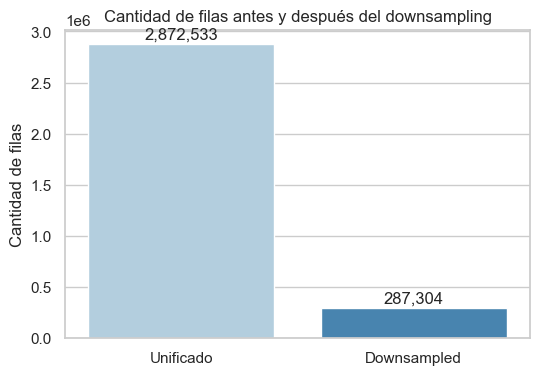

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20676\1680644479.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_bruto['sujeto_id'].value_counts().index.astype(str),
C:\Users\Usuario\AppData\Local\Temp\ipykernel_20676\1680644479.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_ds['sujeto_id'].value_counts().index.astype(str),


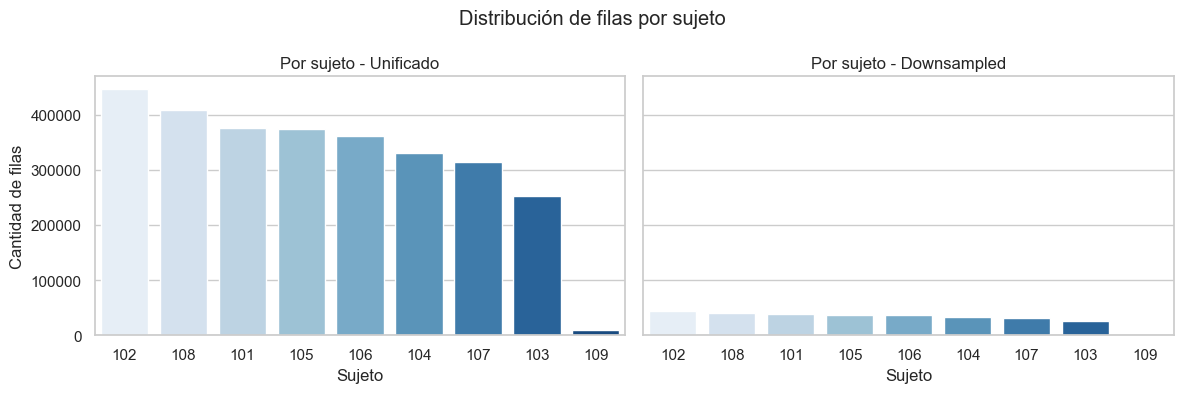

In [7]:
# Gráfico 1: Cantidad de filas antes y después del downsampling
fig, ax = plt.subplots(figsize=(6,4))
etapas = ['Unificado', 'Downsampled']
cantidades = [len(df_bruto), len(df_ds)]
sns.barplot(x=etapas, y=cantidades, ax=ax, palette='Blues')
ax.set_title('Cantidad de filas antes y después del downsampling')
ax.set_ylabel('Cantidad de filas')
for i, v in enumerate(cantidades):
    ax.text(i, v + max(cantidades)*0.01, f'{v:,}', ha='center', va='bottom')
plt.show()

# Gráfico 2: Distribución de filas por sujeto antes y después
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)
sns.barplot(x=df_bruto['sujeto_id'].value_counts().index.astype(str),
            y=df_bruto['sujeto_id'].value_counts().values, ax=axes[0], palette='Blues')
axes[0].set_title('Por sujeto - Unificado')
axes[0].set_xlabel('Sujeto')
axes[0].set_ylabel('Cantidad de filas')
sns.barplot(x=df_ds['sujeto_id'].value_counts().index.astype(str),
            y=df_ds['sujeto_id'].value_counts().values, ax=axes[1], palette='Blues')
axes[1].set_title('Por sujeto - Downsampled')
axes[1].set_xlabel('Sujeto')
plt.suptitle('Distribución de filas por sujeto')
plt.tight_layout()
plt.show()

---
# Paso 1.0: Calidad y limpieza
En este paso se analiza la presencia de valores nulos en el dataset, se visualiza el porcentaje de nulos por columna y se documenta la estrategia de imputación aplicada.

### Paso 1.1: Analizar valores nulos por columna
Se calcula el porcentaje de valores nulos para cada columna del dataset unificado. Esto permite identificar qué columnas tienen problemas de calidad de datos y requieren atención.
No se analizaran las columnas de orientación, ya que se eliminarán por ser inválidas según la documentación oficial.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20676\2113466196.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nulos_pct.index, y=nulos_pct.values, palette='Reds_r')


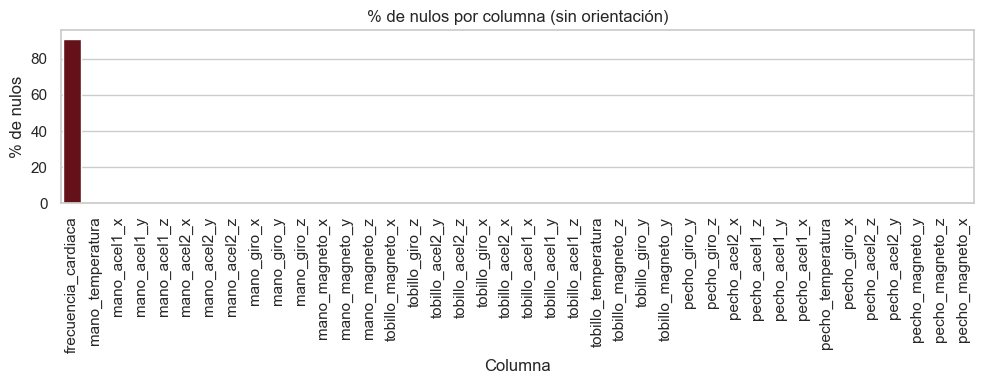

Columnas con nulos (sin orientación):


frecuencia_cardiaca   90.9925
mano_temperatura       0.4636
mano_acel1_x           0.4636
mano_acel1_y           0.4636
mano_acel1_z           0.4636
mano_acel2_x           0.4636
mano_acel2_y           0.4636
mano_acel2_z           0.4636
mano_giro_x            0.4636
mano_giro_y            0.4636
mano_giro_z            0.4636
mano_magneto_x         0.4636
mano_magneto_y         0.4636
mano_magneto_z         0.4636
tobillo_magneto_x      0.4191
tobillo_giro_z         0.4191
tobillo_acel2_y        0.4191
tobillo_acel2_z        0.4191
tobillo_giro_x         0.4191
tobillo_acel2_x        0.4191
tobillo_acel1_x        0.4191
tobillo_acel1_y        0.4191
tobillo_acel1_z        0.4191
tobillo_temperatura    0.4191
tobillo_magneto_z      0.4191
tobillo_giro_y         0.4191
tobillo_magneto_y      0.4191
pecho_giro_y           0.1267
pecho_giro_z           0.1267
pecho_acel2_x          0.1267
pecho_acel1_z          0.1267
pecho_acel1_y          0.1267
pecho_acel1_x          0.1267
pecho_temp

In [8]:
# Análisis de nulos por columna (EXCLUYENDO columnas de orientación)
columnas_a_analizar = [col for col in df_ds.columns if ('orientacion' not in col)]
nulos_pct = df_ds[columnas_a_analizar].isnull().mean() * 100
nulos_pct = nulos_pct[nulos_pct > 0].sort_values(ascending=False)
plt.figure(figsize=(10,4))
sns.barplot(x=nulos_pct.index, y=nulos_pct.values, palette='Reds_r')
plt.title('% de nulos por columna (sin orientación)')
plt.ylabel('% de nulos')
plt.xlabel('Columna')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print('Columnas con nulos (sin orientación):')
display(nulos_pct)

#### Tratamiento de NaNs en frecuencia_cardiaca

La columna `frecuencia_cardiaca` presenta muchos valores faltantes (NaN) porque el sensor de pulso muestrea a ~9 Hz, mientras que las IMUs lo hacen a 100 Hz. Esto genera NaNs estructurales, no errores de medición.

**Estrategia aplicada:**
- Se realiza interpolación lineal dentro de cada `sujeto_id` usando pandas (`groupby` + `interpolate`).
- La interpolación lineal estima los valores faltantes suponiendo que la variación entre dos mediciones conocidas es continua y uniforme.
- Para los NaN en los extremos (inicio o fin de cada sujeto), se aplica forward-fill y backward-fill para completar con el valor más cercano disponible.
- Así se preserva la continuidad temporal y no se mezclan datos entre sujetos.

In [9]:
nan_antes = df_ds['frecuencia_cardiaca'].isna().sum()
pct_antes = nan_antes / len(df_ds) * 100
print(f'NaNs en frecuencia_cardiaca ANTES:   {nan_antes:,}  ({pct_antes:.1f}%)')

df_limpio = df_ds.copy()
df_limpio['frecuencia_cardiaca'] = (
    df_limpio.groupby('sujeto_id')['frecuencia_cardiaca']
            .transform(lambda x: x.interpolate(method='linear').ffill().bfill())
)

nan_despues = df_limpio['frecuencia_cardiaca'].isna().sum()
print(f'NaNs en frecuencia_cardiaca DESPUES: {nan_despues:,}')
print(f'NaNs resueltos:             {nan_antes - nan_despues:,}')


NaNs en frecuencia_cardiaca ANTES:   261,425  (91.0%)
NaNs en frecuencia_cardiaca DESPUES: 0
NaNs resueltos:             261,425


#### Eliminación de filas con datos faltantes

En el análisis previo, se imputaron los valores nulos de frecuencia cardíaca. Sin embargo, persisten valores nulos en otras variables. Dado que representan un porcentaje muy bajo del total de datos, se decide eliminar las filas restantes con datos faltantes para asegurar la calidad del dataset.

A continuación, se muestra la cantidad de filas antes y después de la eliminación, y el porcentaje de datos eliminados.

In [10]:
# Eliminar filas con al menos un valor nulo en las columnas analizadas (sin orientación ni frecuencia_cardiaca)
columnas_con_nulos = [col for col in nulos_pct.index if col in df_limpio.columns and df_limpio[col].isnull().any()]
df_limpio = df_limpio.dropna(subset=columnas_con_nulos)

print("Columnas con nulos detectadas:", columnas_con_nulos)
print("Cantidad de filas antes:", df_ds.shape[0])
print("Cantidad de filas después:", df_limpio.shape[0])

filas_post_dropna = len(df_limpio)  # para resumen 6.3

Columnas con nulos detectadas: ['mano_temperatura', 'mano_acel1_x', 'mano_acel1_y', 'mano_acel1_z', 'mano_acel2_x', 'mano_acel2_y', 'mano_acel2_z', 'mano_giro_x', 'mano_giro_y', 'mano_giro_z', 'mano_magneto_x', 'mano_magneto_y', 'mano_magneto_z', 'tobillo_magneto_x', 'tobillo_giro_z', 'tobillo_acel2_y', 'tobillo_acel2_z', 'tobillo_giro_x', 'tobillo_acel2_x', 'tobillo_acel1_x', 'tobillo_acel1_y', 'tobillo_acel1_z', 'tobillo_temperatura', 'tobillo_magneto_z', 'tobillo_giro_y', 'tobillo_magneto_y', 'pecho_giro_y', 'pecho_giro_z', 'pecho_acel2_x', 'pecho_acel1_z', 'pecho_acel1_y', 'pecho_acel1_x', 'pecho_temperatura', 'pecho_giro_x', 'pecho_acel2_z', 'pecho_acel2_y', 'pecho_magneto_y', 'pecho_magneto_z', 'pecho_magneto_x']
Cantidad de filas antes: 287304
Cantidad de filas después: 284478


#### Chequeo de columnas con nulos nuevamente

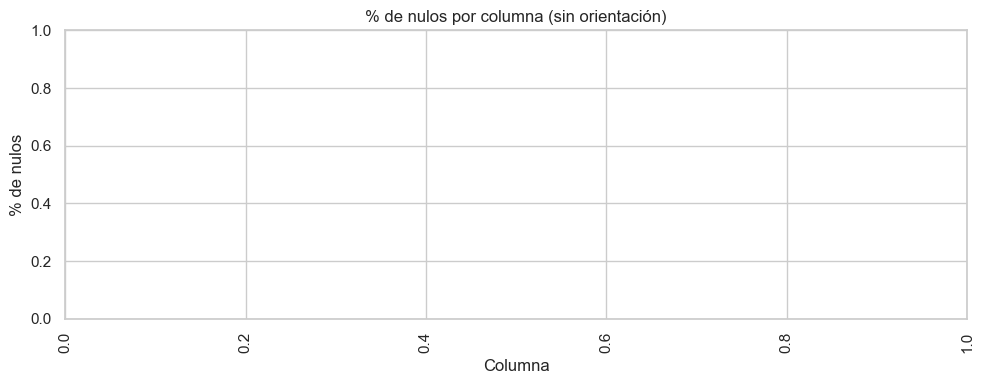

Columnas con nulos:


Series([], dtype: float64)

In [11]:
# Análisis de nulos por columna (EXCLUYENDO columnas de orientación)
columnas_a_analizar = [col for col in df_limpio.columns if ('orientacion' not in col)]
nulos_pct = df_limpio[columnas_a_analizar].isnull().mean() * 100
nulos_pct = nulos_pct[nulos_pct > 0].sort_values(ascending=False)
plt.figure(figsize=(10,4))
sns.barplot(x=nulos_pct.index, y=nulos_pct.values, palette='Reds_r')
plt.title('% de nulos por columna (sin orientación)')
plt.ylabel('% de nulos')
plt.xlabel('Columna')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print('Columnas con nulos:')
display(nulos_pct)

### Comparación visual antes y después de eliminar filas con nulos

A continuación se presentan gráficos comparativos de la distribución de valores en las variables principales antes y después de eliminar las filas con datos faltantes. Esto permite visualizar el impacto de la limpieza sobre el dataset.

C:\Users\Usuario\AppData\Local\Temp\ipykernel_20676\4112756288.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=etapas, y=cantidades, ax=ax, palette='Blues')


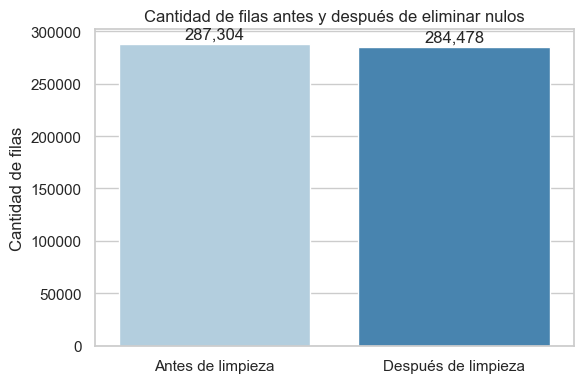

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

etapas = ['Antes de limpieza', 'Después de limpieza']
cantidades = [len(df_ds), len(df_limpio)]
fig, ax = plt.subplots(figsize=(6,4))
sns.barplot(x=etapas, y=cantidades, ax=ax, palette='Blues')
ax.set_title('Cantidad de filas antes y después de eliminar nulos')
ax.set_ylabel('Cantidad de filas')
for i, v in enumerate(cantidades):
    ax.text(i, v + max(cantidades)*0.01, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

### Paso 1.2: Verificación de duplicados

Se verifica que no existan filas duplicadas usando la clave natural del dataset: la combinación de `sujeto_id` + `tiempo`. Cada muestra temporal por sujeto debe ser única. Si se detectan duplicados, se eliminan.

In [13]:
# Verificación de duplicados por clave natural (sujeto_id + tiempo)
n_total = len(df_limpio)
n_dup = df_limpio.duplicated(subset=['sujeto_id', 'tiempo']).sum()

print(f'Total filas:                           {n_total:,}')
print(f'Filas duplicadas (sujeto_id + tiempo): {n_dup:,}')

if n_dup == 0:
    print('Sin duplicados detectados — dataset íntegro.')
else:
    pct = n_dup / n_total * 100
    print(f'Porcentaje de duplicados: {pct:.2f}%')
    df_limpio = df_limpio.drop_duplicates(subset=['sujeto_id', 'tiempo'])
    print(f'Filas después de eliminar duplicados: {len(df_limpio):,}')

Total filas:                           284,478
Filas duplicadas (sujeto_id + tiempo): 0
Sin duplicados detectados — dataset íntegro.


### Paso 1.3: Análisis de valores extremos

Se analiza la presencia de valores mínimos y máximos por variable para detectar valores imposibles o errores de sensor. Los boxplots permiten visualizar la distribución y la presencia de puntos atípicos.

**Nota:** La detección y **eliminación** de outliers por método IQR se realiza en el **Paso 1.9**, después de excluir los registros transitorios (actividad_id = 0), agrupando por actividad y columna.

### Pasos 1.4, 1.5 y 1.6: Espacios, encoding, caracteres especiales, casing y homogeneidad (no aplica)
No existen columnas de texto en el dataset PAMAP2 donde puedan aparecer espacios, problemas de encoding, caracteres especiales, mayúsculas/minúsculas o falta de homogeneidad en los valores. Todas las variables son numéricas o IDs.

### Paso 1.7: Eliminación de columnas inválidas (orientación IMU)

Según la documentación oficial del dataset PAMAP2 (`readme.pdf`, UCI), las columnas de orientación de los tres sensores IMU son **inválidas** en esta recolección. La calibración de los quaterniones no fue completada correctamente durante la toma de datos.

Se eliminan las **12 columnas** de orientación (4 por IMU × 3 IMUs: mano, pecho, tobillo), reduciendo el dataset de 55 → 43 columnas.

In [14]:
print('Columnas de orientación eliminadas:')
for col in ORIENT_COLS:
    print(f'  - {col}')

cols_antes = df_limpio.shape[1]
df_limpio = df_limpio.drop(columns=ORIENT_COLS)

print()
print(f'Columnas antes:   {cols_antes}')
print(f'Columnas despues: {df_limpio.shape[1]}  (menos {cols_antes - df_limpio.shape[1]})')
print(f'Shape resultante: {df_limpio.shape}')

Columnas de orientación eliminadas:
  - mano_orientacion_1
  - mano_orientacion_2
  - mano_orientacion_3
  - mano_orientacion_4
  - pecho_orientacion_1
  - pecho_orientacion_2
  - pecho_orientacion_3
  - pecho_orientacion_4
  - tobillo_orientacion_1
  - tobillo_orientacion_2
  - tobillo_orientacion_3
  - tobillo_orientacion_4

Columnas antes:   55
Columnas despues: 43  (menos 12)
Shape resultante: (284478, 43)


### Paso 1.8: Exclusión de registros transitorios (actividad_id = 0)

El valor `actividad_id = 0` está etiquetado como *"other"* en el dataset y corresponde a **períodos transitorios** entre actividades. Estos registros no representan ninguna actividad definida del protocolo, introducen ambigüedad en los patrones de señal y son ruido para el modelo de clasificación.

Se excluyen completamente del dataset de trabajo.

Filas antes:                   284,478
Filas con actividad_id == 0:    92,343  (32.5%)
Filas despues:                 192,135

Actividades presentes (12): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(12), np.int64(13), np.int64(16), np.int64(17), np.int64(24)]


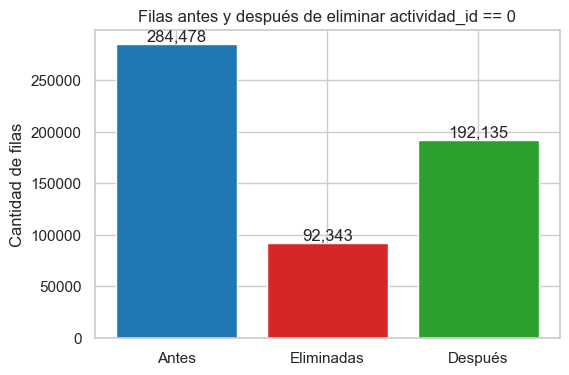

In [15]:
filas_antes = len(df_limpio)
df_limpio = df_limpio[df_limpio['actividad_id'] != 0].copy()
filas_despues = len(df_limpio)
eliminadas = filas_antes - filas_despues

print(f'Filas antes:                 {filas_antes:>9,}')
print(f'Filas con actividad_id == 0: {eliminadas:>9,}  ({eliminadas/filas_antes*100:.1f}%)')
print(f'Filas despues:               {filas_despues:>9,}')
print()
acts = sorted(df_limpio['actividad_id'].unique())
n_acts = df_limpio['actividad_id'].nunique()
print(f'Actividades presentes ({n_acts}): {acts}')

# Gráfico de barras antes y después
import matplotlib.pyplot as plt
import numpy as np

labels = ['Antes', 'Eliminadas', 'Después']
values = [filas_antes, eliminadas, filas_despues]
colors = ['#1f77b4', '#d62728', '#2ca02c']

fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(labels, values, color=colors)
ax.bar_label(bars, fmt='{:,.0f}')
ax.set_ylabel('Cantidad de filas')
ax.set_title('Filas antes y después de eliminar actividad_id == 0')
plt.show()

filas_post_act0 = filas_despues  # para resumen 6.3

### Paso 1.9: Eliminación de outliers por IQR (por actividad y columna)

Se aplica el método IQR (Rango Intercuartílico) para detectar y **eliminar** valores extremos. A diferencia de un IQR global, aquí se calcula por separado para cada combinación de **actividad × columna**.

**Motivo del agrupamiento por actividad:** los rangos fisiológicos de frecuencia cardíaca y movimiento difieren notablemente entre actividades (ej: lying vs running). Un IQR global mezclaría distribuciones distintas y marcaría como outlier valores perfectamente normales en una actividad de alta intensidad.

**Regla:** se elimina toda fila donde al menos una de las variables clave caiga fuera de [Q1 − 1.5×IQR, Q3 + 1.5×IQR] para su actividad correspondiente.

In [16]:
variables_iqr = [
    'frecuencia_cardiaca',
    'mano_acel1_x', 'mano_acel1_y', 'mano_acel1_z',
    'pecho_acel1_x', 'pecho_acel1_y', 'pecho_acel1_z',
    'tobillo_acel1_x', 'tobillo_acel1_y', 'tobillo_acel1_z',
    'mano_giro_x', 'mano_giro_y', 'mano_giro_z',
]

mask_outlier = pd.Series(False, index=df_limpio.index)
resumen_out = []

for col in variables_iqr:
    for act_id in sorted(df_limpio['actividad_id'].unique()):
        mask_act = df_limpio['actividad_id'] == act_id
        subset = df_limpio.loc[mask_act, col]
        Q1 = subset.quantile(0.25)
        Q3 = subset.quantile(0.75)
        IQR = Q3 - Q1
        is_out = mask_act & ((df_limpio[col] < Q1 - 1.5 * IQR) | (df_limpio[col] > Q3 + 1.5 * IQR))
        mask_outlier = mask_outlier | is_out
        n_out = int(is_out.sum())
        if n_out > 0:
            resumen_out.append({
                'actividad_id': act_id,
                'columna': col,
                'outliers': n_out,
                '% de la actividad': round(n_out / mask_act.sum() * 100, 2)
            })

print('Outliers detectados por actividad y columna (IQR 1.5×):')
display(pd.DataFrame(resumen_out))

filas_antes_out = len(df_limpio)
df_limpio = df_limpio[~mask_outlier].copy()
filas_post_outliers = len(df_limpio)

print(f'\nFilas antes de eliminar outliers: {filas_antes_out:,}')
print(f'Filas eliminadas:                 {filas_antes_out - filas_post_outliers:,}  ({(filas_antes_out - filas_post_outliers)/filas_antes_out*100:.1f}%)')
print(f'Filas después:                    {filas_post_outliers:,}')

Outliers detectados por actividad y columna (IQR 1.5×):


,actividad_id,columna,outliers,% de la actividad
0,1,frecuencia_cardiaca,840,4.3700
1,2,frecuencia_cardiaca,620,3.3600
2,5,frecuencia_cardiaca,116,1.2100
3,6,frecuencia_cardiaca,176,1.0800
4,7,frecuencia_cardiaca,523,2.8400
...,...,...,...,...
145,12,mano_giro_z,1061,9.0600
146,13,mano_giro_z,639,6.0900
147,16,mano_giro_z,1073,6.1300
148,17,mano_giro_z,1918,8.0600



Filas antes de eliminar outliers: 192,135
Filas eliminadas:                 82,323  (42.8%)
Filas después:                    109,812


### Visualización: reducción de filas a lo largo del pipeline ETL

El siguiente gráfico muestra cuántas filas quedan después de cada etapa de limpieza, desde el dataset bruto (100 Hz) hasta el dataset final sin outliers.

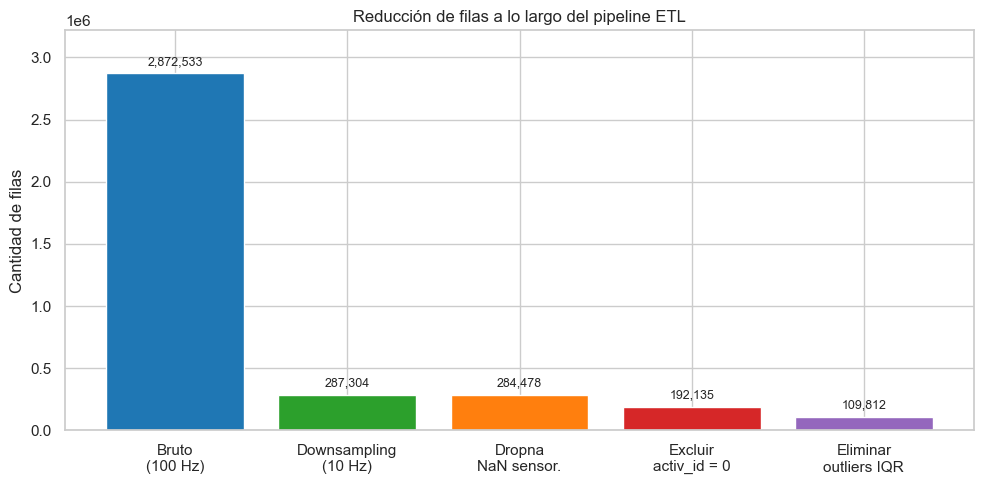

In [17]:
# Reducción de filas a lo largo del pipeline ETL
etapas = [
    'Bruto\n(100 Hz)',
    'Downsampling\n(10 Hz)',
    'Dropna\nNaN sensor.',
    'Excluir\nactiv_id = 0',
    'Eliminar\noutliers IQR',
]
filas = [len(df_bruto), len(df_ds), filas_post_dropna, filas_post_act0, filas_post_outliers]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(etapas, filas, color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd'])
ax.bar_label(bars, labels=[f'{v:,}' for v in filas], padding=4, fontsize=9)
ax.set_ylabel('Cantidad de filas')
ax.set_title('Reducción de filas a lo largo del pipeline ETL')
ax.set_ylim(0, max(filas) * 1.12)
plt.tight_layout()
plt.savefig(FIGURES_PATH / 'fig_pipeline_reduccion.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 2. Tipos de datos

### Paso 2.1: Casteo y verificación de tipos

Se verifican los tipos de datos de cada columna. Se espera:
- `actividad_id` y `sujeto_id`: enteros (`int`)
- `tiempo`: float (segundos desde inicio de sesión)
- Variables sensoriales: `float64`

Al leer los archivos `.dat` con pandas (sin header, valores separados por espacios), todas las columnas se infieren como `float64`. Se castean `actividad_id` y `sujeto_id` a `int`.

In [18]:
# Verificación y casteo de tipos de datos
print('Tipos de datos actuales:')
display(df_limpio.dtypes.to_frame('dtype').T)

# actividad_id y sujeto_id provienen de float64 (archivos .dat sin header)
df_limpio['actividad_id'] = df_limpio['actividad_id'].astype(int)
df_limpio['sujeto_id']    = df_limpio['sujeto_id'].astype(int)

print('\nTipos tras casteo de actividad_id y sujeto_id a int:')
display(df_limpio.dtypes.to_frame('dtype').T)
print('\nMemoria tras casteo:', round(df_limpio.memory_usage(deep=True).sum() / 1e6, 1), 'MB')

Tipos de datos actuales:


,tiempo,actividad_id,frecuencia_cardiaca,mano_temperatura,mano_acel1_x,mano_acel1_y,mano_acel1_z,mano_acel2_x,mano_acel2_y,mano_acel2_z,mano_giro_x,mano_giro_y,mano_giro_z,mano_magneto_x,mano_magneto_y,mano_magneto_z,pecho_temperatura,pecho_acel1_x,pecho_acel1_y,pecho_acel1_z,pecho_acel2_x,pecho_acel2_y,pecho_acel2_z,pecho_giro_x,pecho_giro_y,pecho_giro_z,pecho_magneto_x,pecho_magneto_y,pecho_magneto_z,tobillo_temperatura,tobillo_acel1_x,tobillo_acel1_y,tobillo_acel1_z,tobillo_acel2_x,tobillo_acel2_y,tobillo_acel2_z,tobillo_giro_x,tobillo_giro_y,tobillo_giro_z,tobillo_magneto_x,tobillo_magneto_y,tobillo_magneto_z,sujeto_id
dtype,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64



Tipos tras casteo de actividad_id y sujeto_id a int:


,tiempo,actividad_id,frecuencia_cardiaca,mano_temperatura,mano_acel1_x,mano_acel1_y,mano_acel1_z,mano_acel2_x,mano_acel2_y,mano_acel2_z,mano_giro_x,mano_giro_y,mano_giro_z,mano_magneto_x,mano_magneto_y,mano_magneto_z,pecho_temperatura,pecho_acel1_x,pecho_acel1_y,pecho_acel1_z,pecho_acel2_x,pecho_acel2_y,pecho_acel2_z,pecho_giro_x,pecho_giro_y,pecho_giro_z,pecho_magneto_x,pecho_magneto_y,pecho_magneto_z,tobillo_temperatura,tobillo_acel1_x,tobillo_acel1_y,tobillo_acel1_z,tobillo_acel2_x,tobillo_acel2_y,tobillo_acel2_z,tobillo_giro_x,tobillo_giro_y,tobillo_giro_z,tobillo_magneto_x,tobillo_magneto_y,tobillo_magneto_z,sujeto_id
dtype,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64



Memoria tras casteo: 38.7 MB


### Pasos 2.2 y 2.3: Fechas/timestamps y booleanos (no aplica)

El campo `tiempo` es numérico en segundos (float), no un objeto datetime. El dataset no contiene columnas booleanas ni flags.

---
## 3. Normalización y estandarización

### Paso 3.1: Valores de dominio — actividad_id y sujeto_id

Se verifican y visualizan los valores únicos de las columnas identificadoras para confirmar que son coherentes con el protocolo del dataset. No se requiere normalización: ambas columnas son identificadores numéricos correctos.

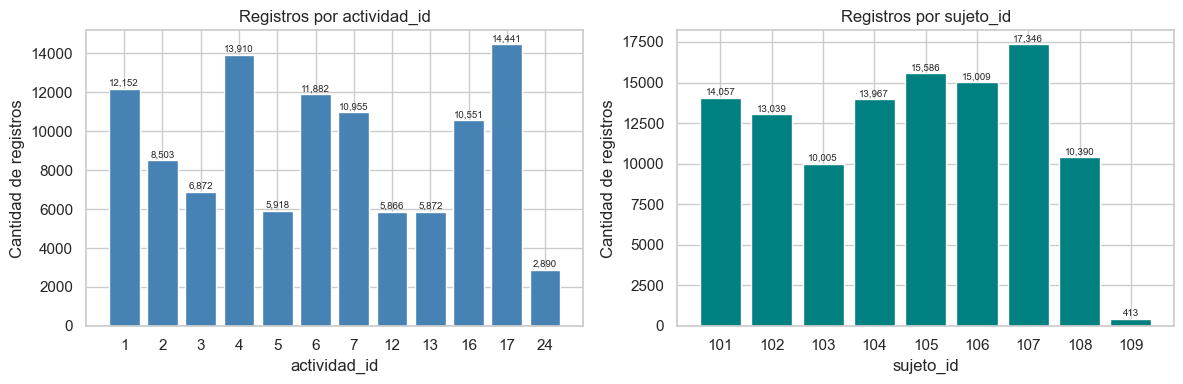

Valores únicos de actividad_id: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(12), np.int64(13), np.int64(16), np.int64(17), np.int64(24)]
Valores únicos de sujeto_id:    [np.int64(101), np.int64(102), np.int64(103), np.int64(104), np.int64(105), np.int64(106), np.int64(107), np.int64(108), np.int64(109)]


In [19]:
# Visualización de valores únicos de actividad_id y sujeto_id
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

act_counts = df_limpio['actividad_id'].value_counts().sort_index()
axes[0].bar(act_counts.index.astype(str), act_counts.values, color='steelblue')
axes[0].set_title('Registros por actividad_id')
axes[0].set_xlabel('actividad_id')
axes[0].set_ylabel('Cantidad de registros')
for bar, v in zip(axes[0].patches, act_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{v:,}', ha='center', va='bottom', fontsize=7)

subj_counts = df_limpio['sujeto_id'].value_counts().sort_index()
axes[1].bar(subj_counts.index.astype(str), subj_counts.values, color='teal')
axes[1].set_title('Registros por sujeto_id')
axes[1].set_xlabel('sujeto_id')
axes[1].set_ylabel('Cantidad de registros')
for bar, v in zip(axes[1].patches, subj_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{v:,}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(FIGURES_PATH / 'fig_dominio_actividad_sujeto.png', dpi=100, bbox_inches='tight')
plt.show()

print('Valores únicos de actividad_id:', sorted(df_limpio['actividad_id'].unique()))
print('Valores únicos de sujeto_id:   ', sorted(df_limpio['sujeto_id'].unique()))

### Paso 3.2: Unidades de medida

| Variable | Unidad |
|---|---|
| `tiempo` | segundos (s) |
| `frecuencia_cardiaca` | latidos por minuto (bpm) |
| `*_temperatura` | grados Celsius (°C) |
| `*_acel1_x/y/z` | m/s² (escala ±16g, 13-bit) |
| `*_acel2_x/y/z` | m/s² (escala ±6g, 13-bit) |
| `*_giro_x/y/z` | rad/s |
| `*_magneto_x/y/z` | µT (microtesla) |

### Paso 3.3: Estrategia de escalado numérico (documentación)

**Estrategia elegida:** `StandardScaler` (z-score normalization), por columna.

**Motivo:** las variables tienen unidades y rangos muy distintos (°C, bpm, m/s², rad/s, µT). El StandardScaler garantiza media = 0 y desvío estándar = 1 por columna, haciendo las magnitudes comparables para los modelos de clasificación.

In [20]:

# Identificar columnas numéricas
num_cols = df_limpio.select_dtypes(include=[np.number]).columns.tolist()
exclude = ['tiempo', 'actividad_id', 'sujeto_id']
cols_to_scale = [c for c in num_cols if c not in exclude]
print(f'Columnas a escalar ({len(cols_to_scale)}):', cols_to_scale)
# Copia del DataFrame para mantener el original
df_limpio_original = df_limpio.copy()
# Aplicar scaler (evitar error si no hay columnas para escalar)
if cols_to_scale:
    scaler = StandardScaler()
    df_limpio[cols_to_scale] = scaler.fit_transform(df_limpio[cols_to_scale])
    print('StandardScaler aplicado exitosamente.')
else:
    print('No hay columnas numéricas para escalar (excluidas las columnas reservadas).')
# Opcional: mostrar estadísticos antes/después (primeras 3 columnas escaladas)
display(df_limpio_original[cols_to_scale[:3]].describe().round(4))
display(df_limpio[cols_to_scale[:3]].describe().round(4))

Columnas a escalar (40): ['frecuencia_cardiaca', 'mano_temperatura', 'mano_acel1_x', 'mano_acel1_y', 'mano_acel1_z', 'mano_acel2_x', 'mano_acel2_y', 'mano_acel2_z', 'mano_giro_x', 'mano_giro_y', 'mano_giro_z', 'mano_magneto_x', 'mano_magneto_y', 'mano_magneto_z', 'pecho_temperatura', 'pecho_acel1_x', 'pecho_acel1_y', 'pecho_acel1_z', 'pecho_acel2_x', 'pecho_acel2_y', 'pecho_acel2_z', 'pecho_giro_x', 'pecho_giro_y', 'pecho_giro_z', 'pecho_magneto_x', 'pecho_magneto_y', 'pecho_magneto_z', 'tobillo_temperatura', 'tobillo_acel1_x', 'tobillo_acel1_y', 'tobillo_acel1_z', 'tobillo_acel2_x', 'tobillo_acel2_y', 'tobillo_acel2_z', 'tobillo_giro_x', 'tobillo_giro_y', 'tobillo_giro_z', 'tobillo_magneto_x', 'tobillo_magneto_y', 'tobillo_magneto_z']
StandardScaler aplicado exitosamente.


,frecuencia_cardiaca,mano_temperatura,mano_acel1_x
count,109812.0000,109812.0000,109812.0000
mean,107.4244,32.6303,-4.6671
std,27.4096,1.7915,5.3597
min,57.0000,24.8750,-37.7045
25%,85.8182,31.4375,-8.6783
50%,106.0000,33.0000,-5.2013
75%,124.0000,33.8750,-1.1390
max,202.0000,35.5000,20.4631


,frecuencia_cardiaca,mano_temperatura,mano_acel1_x
count,109812.0000,109812.0000,109812.0000
mean,0.0000,-0.0000,0.0000
std,1.0000,1.0000,1.0000
min,-1.8397,-4.3290,-6.1640
25%,-0.7883,-0.6658,-0.7484
50%,-0.0520,0.2064,-0.0997
75%,0.6047,0.6948,0.6583
max,3.4505,1.6019,4.6887


---
## 4. Enriquecimiento y derivación de columnas

### Pasos 4.1, 4.2 y 4.3: Columnas derivadas, lookup externo y metadatos

No se incorporan columnas derivadas dada la naturaleza del dataset PAMAP2, tampoco se requiere lookup externo ni metadatos adicionales para el análisis de actividades físicas. Las variables originales ya capturan la información relevante para el modelado.

---
## 5. Estructura del schema

### Pasos 5.1 y 5.2: Renombre y selección de columnas (ya realizados)

- **5.1 — Renombre:** los nombres de columna se asignaron manualmente al cargar los archivos `.dat` (que no incluyen header), mediante `RAW_COLUMNAS` (Paso 0.3). Los nombres están en español y son descriptivos.
- **5.2 — Drop de columnas:** las 12 columnas de orientación (inválidas según UCI) fueron eliminadas en el Paso 1.7. El dataset resultante tiene **43 columnas**.

In [21]:
# Listado de columnas del dataset final
print(f'Columnas del dataset final ({df_limpio.shape[1]}):')
for i, col in enumerate(df_limpio.columns, 1):
    print(f'  {i:2d}. {col}')

Columnas del dataset final (43):
   1. tiempo
   2. actividad_id
   3. frecuencia_cardiaca
   4. mano_temperatura
   5. mano_acel1_x
   6. mano_acel1_y
   7. mano_acel1_z
   8. mano_acel2_x
   9. mano_acel2_y
  10. mano_acel2_z
  11. mano_giro_x
  12. mano_giro_y
  13. mano_giro_z
  14. mano_magneto_x
  15. mano_magneto_y
  16. mano_magneto_z
  17. pecho_temperatura
  18. pecho_acel1_x
  19. pecho_acel1_y
  20. pecho_acel1_z
  21. pecho_acel2_x
  22. pecho_acel2_y
  23. pecho_acel2_z
  24. pecho_giro_x
  25. pecho_giro_y
  26. pecho_giro_z
  27. pecho_magneto_x
  28. pecho_magneto_y
  29. pecho_magneto_z
  30. tobillo_temperatura
  31. tobillo_acel1_x
  32. tobillo_acel1_y
  33. tobillo_acel1_z
  34. tobillo_acel2_x
  35. tobillo_acel2_y
  36. tobillo_acel2_z
  37. tobillo_giro_x
  38. tobillo_giro_y
  39. tobillo_giro_z
  40. tobillo_magneto_x
  41. tobillo_magneto_y
  42. tobillo_magneto_z
  43. sujeto_id


### Paso 5.3: Pivot / unpivot (no aplica)

El dataset tiene su formato en una fila por muestra de tiempo, una columna por variable. No se requiere reestructuración.

---
## 6. Validaciones y reglas de negocio

### Paso 6.1: Rangos y formatos válidos

Se validan los rangos esperados de las variables clave contra límites fisiológicos y físicos del sensor:

| Variable | Rango esperado |
|---|---|
| `frecuencia_cardiaca` | 40 – 220 bpm |
| `*_temperatura` | 20 – 42 °C |
| `*_acel1_x/y/z` | −200 a 200 m/s² |
| `*_acel2_x/y/z` | −80 a 80 m/s² |
| `*_giro_x/y/z` | −35 a 35 rad/s |

In [22]:
# Validación de rangos fisiológicos y físicos por variable
rangos = {
    'frecuencia_cardiaca': (40, 220),
    'mano_temperatura':    (20, 42),  'pecho_temperatura':   (20, 42),  'tobillo_temperatura': (20, 42),
    'mano_acel1_x':   (-200, 200),   'mano_acel1_y':   (-200, 200),   'mano_acel1_z':   (-200, 200),
    'pecho_acel1_x':  (-200, 200),   'pecho_acel1_y':  (-200, 200),   'pecho_acel1_z':  (-200, 200),
    'tobillo_acel1_x':(-200, 200),   'tobillo_acel1_y':(-200, 200),   'tobillo_acel1_z':(-200, 200),
    'mano_acel2_x':   (-80, 80),     'mano_acel2_y':   (-80, 80),     'mano_acel2_z':   (-80, 80),
    'pecho_acel2_x':  (-80, 80),     'pecho_acel2_y':  (-80, 80),     'pecho_acel2_z':  (-80, 80),
    'tobillo_acel2_x':(-80, 80),     'tobillo_acel2_y':(-80, 80),     'tobillo_acel2_z':(-80, 80),
    'mano_giro_x':    (-35, 35),     'mano_giro_y':    (-35, 35),     'mano_giro_z':    (-35, 35),
    'pecho_giro_x':   (-35, 35),     'pecho_giro_y':   (-35, 35),     'pecho_giro_z':   (-35, 35),
    'tobillo_giro_x': (-35, 35),     'tobillo_giro_y': (-35, 35),     'tobillo_giro_z': (-35, 35),
}

resultados_val = []
for col, (vmin, vmax) in rangos.items():
    if col not in df_limpio_original.columns:
        continue
    fuera = df_limpio_original[(df_limpio_original[col] < vmin) | (df_limpio_original[col] > vmax)].shape[0]
    total = df_limpio_original[col].notna().sum()
    resultados_val.append({'columna': col, 'rango_min': vmin, 'rango_max': vmax,
                           'fuera_de_rango': fuera, '% fuera': round(fuera/total*100, 3) if total else 0})

df_val = pd.DataFrame(resultados_val)
fuera_total = df_val['fuera_de_rango'].sum()
if fuera_total == 0:
    print('Todas las variables están dentro de los rangos esperados.')
else:
    print(f'Variables con valores fuera de rango ({fuera_total:,} registros en total):')
    display(df_val[df_val['fuera_de_rango'] > 0])

Todas las variables están dentro de los rangos esperados.


### Paso 6.2: Integridad referencial

Se verifica que todos los valores de `actividad_id` pertenezcan al catálogo oficial del dataset PAMAP2, y que todos los `sujeto_id` sean válidos (101 a 109).

In [23]:
# Verificación de integridad referencial
ACTIVIDADES_VALIDAS = {1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 16, 17, 18, 19, 20, 24}
SUJETOS_VALIDOS = set(range(101, 110))

act_invalidas = df_limpio[~df_limpio['actividad_id'].isin(ACTIVIDADES_VALIDAS)]
suj_invalidos  = df_limpio[~df_limpio['sujeto_id'].isin(SUJETOS_VALIDOS)]

print(f'Registros con actividad_id fuera del catálogo: {len(act_invalidas):,}')
print(f'Registros con sujeto_id fuera de rango 101-109: {len(suj_invalidos):,}')

if len(act_invalidas) == 0 and len(suj_invalidos) == 0:
    print('\nIntegridad referencial OK — sin registros inválidos.')
else:
    if len(act_invalidas) > 0:
        print('\nActividades fuera del catálogo:')
        display(act_invalidas['actividad_id'].value_counts())
    if len(suj_invalidos) > 0:
        print('\nSujetos fuera de rango:')
        display(suj_invalidos['sujeto_id'].value_counts())

Registros con actividad_id fuera del catálogo: 0
Registros con sujeto_id fuera de rango 101-109: 0

Integridad referencial OK — sin registros inválidos.


### Paso 6.3: Registros rechazados

Se consolida un resumen cuantitativo de todos los registros descartados a lo largo del pipeline ETL, con la etapa y justificación de cada descarte.

In [24]:
# Conteo de registros descartados durante todo el pipeline ETL
print('RESUMEN DE DESCARTE DE REGISTROS — PIPELINE ETL')
print('='*65)

pasos = [
    ('Carga bruta (9 sujetos, 100 Hz)',              len(df_bruto),        0),
    ('Tras downsampling (100 → 10 Hz)',               len(df_ds),           len(df_bruto) - len(df_ds)),
    ('Tras eliminar NaN sensoriales (dropna)',        filas_post_dropna,    len(df_ds) - filas_post_dropna),
    ('Tras drop cols orientación (sin cambio filas)', filas_post_dropna,    0),
    ('Tras excluir actividad_id = 0',                 filas_post_act0,      filas_post_dropna - filas_post_act0),
    ('Tras eliminar outliers IQR (por act.)',          filas_post_outliers,  filas_post_act0 - filas_post_outliers),
]

print(f'\n{"Etapa":<50} {"Filas":>8}  {"Descartadas":>12}')
print('-'*74)
for etapa, filas, desc in pasos:
    desc_str = f'{desc:,}' if desc > 0 else '—'
    print(f'{etapa:<50} {filas:>8,}  {desc_str:>12}')

print('-'*74)
total_desc = len(df_bruto) - filas_post_outliers
pct = total_desc / len(df_bruto) * 100
print(f'{"Total descartado del bruto":<50} {"":>8}  {total_desc:>12,}  ({pct:.1f}%)')
print(f'\nDataset final: {len(df_limpio):,} filas × {df_limpio.shape[1]} columnas')
print()
print('Nota: el downsampling descarta muestras por diseño (reducción de frecuencia),')
print('no por error. La información relevante para HAR se preserva íntegramente.')

RESUMEN DE DESCARTE DE REGISTROS — PIPELINE ETL

Etapa                                                 Filas   Descartadas
--------------------------------------------------------------------------
Carga bruta (9 sujetos, 100 Hz)                    2,872,533             —
Tras downsampling (100 → 10 Hz)                     287,304     2,585,229
Tras eliminar NaN sensoriales (dropna)              284,478         2,826
Tras drop cols orientación (sin cambio filas)       284,478             —
Tras excluir actividad_id = 0                       192,135        92,343
Tras eliminar outliers IQR (por act.)               109,812        82,323
--------------------------------------------------------------------------
Total descartado del bruto                                      2,762,721  (96.2%)

Dataset final: 109,812 filas × 43 columnas

Nota: el downsampling descarta muestras por diseño (reducción de frecuencia),
no por error. La información relevante para HAR se preserva íntegramente.


---
## 7. Estrategia de carga

### Paso 7.1: Carga full vs incremental

**Estrategia elegida: carga full (batch completo).**

En cada ejecución del pipeline se procesan los 9 archivos fuente completos desde cero y se genera un nuevo `pamap2_limpio.csv` que reemplaza al anterior.

**Justificación:**
- El dataset PAMAP2 es **estático**: es una captura de laboratorio de 2012, no crece ni recibe nuevas sesiones.
- El volumen es manejable (~130 MB en RAM tras downsampling).
- Una carga incremental solo tendría sentido si se incorporaran nuevos sujetos o sesiones, lo cual no ocurre en este proyecto.

### Paso 7.2: Modo de escritura

**Modo: sobreescritura (`overwrite`).**

El archivo `data/processed/pamap2_limpio.csv` se sobreescribe en cada ejecución del pipeline (`df.to_csv(..., index=False)`).

**Justificación:**
- El dataset procesado es reproducible: dado el mismo input, el output es idéntico.
- No hay riesgo de pérdida de datos: los archivos fuente `.dat` originales se conservan en `PAMAP2_Dataset/Protocol/` y no se modifican nunca.
- En producción con datos acumulativos se usaría modo `append` con control de duplicados; en este contexto no aplica.

### Paso 7.3: Particionado y clustering

El dataset se almacena como un único archivo CSV sin particionado.

**Justificación:**
- El volumen final (~130 MB, ~280K filas) no justifica particionado por ninguna dimensión.
- En un contexto de producción a mayor escala, se podría particionar por `sujeto_id` (útil para LOSO-CV distribuido) o por `actividad_id` (para análisis por clase). Queda documentado como posible mejora.
- No se aplica clustering de almacenamiento (ej: Parquet column groups) ya que el entorno es Google Colab con pandas, no un sistema distribuido.

---
## Verificación final del dataset limpio

Se verifica el estado del DataFrame resultante: shape, tipos de datos y porcentaje
de nulos por columna. El dataset debe tener **0 nulos** antes de ser guardado.

In [25]:
print('=' * 60)
print('VERIFICACION FINAL DEL DATASET LIMPIO')
print('=' * 60)

print(f'Shape: {df_limpio.shape[0]:,} filas x {df_limpio.shape[1]} columnas')

n_acts = df_limpio['actividad_id'].nunique()
print(f'Actividades presentes ({n_acts}):')
print(' ', sorted(df_limpio['actividad_id'].unique()))

n_subjs = df_limpio['sujeto_id'].nunique()
print(f'Sujetos ({n_subjs}):')
print(' ', sorted(df_limpio['sujeto_id'].unique()))

print()
print('DTYPES:')
print(df_limpio.dtypes.to_string())

print()
pct_nulos = df_limpio.isnull().mean() * 100
nulos_nonzero = pct_nulos[pct_nulos > 0]
if len(nulos_nonzero) > 0:
    print('% NULOS POR COLUMNA (solo columnas con nulos):')
    print(nulos_nonzero.sort_values(ascending=False).to_string())
else:
    print('Sin valores nulos en el dataset final.')

print()
print('ESTADISTICOS DESCRIPTIVOS:')
display(df_limpio.describe().round(4))

VERIFICACION FINAL DEL DATASET LIMPIO
Shape: 109,812 filas x 43 columnas
Actividades presentes (12):
  [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(12), np.int64(13), np.int64(16), np.int64(17), np.int64(24)]
Sujetos (9):
  [np.int64(101), np.int64(102), np.int64(103), np.int64(104), np.int64(105), np.int64(106), np.int64(107), np.int64(108), np.int64(109)]

DTYPES:
tiempo                 float64
actividad_id             int64
frecuencia_cardiaca    float64
mano_temperatura       float64
mano_acel1_x           float64
mano_acel1_y           float64
mano_acel1_z           float64
mano_acel2_x           float64
mano_acel2_y           float64
mano_acel2_z           float64
mano_giro_x            float64
mano_giro_y            float64
mano_giro_z            float64
mano_magneto_x         float64
mano_magneto_y         float64
mano_magneto_z         float64
pecho_temperatura      float64
pecho_acel1_x          float64
pecho_acel1_y    

,tiempo,actividad_id,frecuencia_cardiaca,mano_temperatura,mano_acel1_x,mano_acel1_y,mano_acel1_z,mano_acel2_x,mano_acel2_y,mano_acel2_z,mano_giro_x,mano_giro_y,mano_giro_z,mano_magneto_x,mano_magneto_y,mano_magneto_z,pecho_temperatura,pecho_acel1_x,pecho_acel1_y,pecho_acel1_z,pecho_acel2_x,pecho_acel2_y,pecho_acel2_z,pecho_giro_x,pecho_giro_y,pecho_giro_z,pecho_magneto_x,pecho_magneto_y,pecho_magneto_z,tobillo_temperatura,tobillo_acel1_x,tobillo_acel1_y,tobillo_acel1_z,tobillo_acel2_x,tobillo_acel2_y,tobillo_acel2_z,tobillo_giro_x,tobillo_giro_y,tobillo_giro_z,tobillo_magneto_x,tobillo_magneto_y,tobillo_magneto_z,sujeto_id
count,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000,109812.0000
mean,1777.1217,8.3177,0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,104.5738
std,1103.9323,6.2007,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,2.2599
min,31.2000,1.0000,-1.8397,-4.3290,-6.1640,-6.9439,-6.4035,-7.4639,-9.5213,-6.8900,-6.1236,-6.8409,-5.6036,-4.2628,-6.2502,-6.5976,-2.7190,-5.3559,-6.7471,-2.7503,-7.2307,-7.8030,-2.9607,-10.6986,-9.0354,-7.6668,-4.2742,-4.9816,-2.7252,-3.0838,-4.9751,-5.5516,-5.2141,-13.6591,-12.4952,-14.3698,-11.2330,-8.9385,-5.7606,-7.6372,-6.4315,-5.5184,101.0000
25%,844.3150,3.0000,-0.7883,-0.6658,-0.7484,-0.4957,-0.7241,-0.7392,-0.4830,-0.7189,-0.3386,-0.2735,-0.2446,-0.7414,-0.6544,-0.7060,-0.6691,-0.5071,-0.5610,-0.5744,-0.4991,-0.5586,-0.5765,-0.2662,-0.2446,-0.3663,-0.6279,-0.5439,-0.6568,-0.6849,-0.1099,-0.3221,-0.5949,-0.1165,-0.3178,-0.5901,-0.2250,-0.0910,-0.2439,-0.5454,-0.6477,-0.7833,103.0000
50%,1664.3650,6.0000,-0.0520,0.2064,-0.0997,-0.0345,-0.0520,-0.0910,-0.0299,-0.0365,0.0126,-0.0166,-0.0521,0.0347,-0.0940,0.0182,0.1509,0.1063,0.3470,-0.0545,0.1069,0.3281,-0.0479,0.0476,-0.0164,0.0220,-0.1272,-0.1822,-0.0663,0.2419,0.1331,0.1060,0.0028,0.1494,0.0875,0.0043,0.0237,0.0402,-0.0308,-0.1413,-0.0586,0.0437,105.0000
75%,2760.9025,16.0000,0.6047,0.6948,0.6583,0.5929,0.8158,0.6554,0.5666,0.8233,0.2885,0.2329,0.2017,0.7754,0.7168,0.6806,0.8479,0.5344,0.5360,0.3508,0.5154,0.5335,0.3602,0.3270,0.2642,0.3175,0.5535,0.3605,0.7317,0.7871,0.2364,0.4744,0.6187,0.2454,0.4552,0.6019,0.1178,0.2418,0.0125,0.7936,0.7923,0.7283,107.0000
max,4245.6700,24.0000,3.4505,1.6019,4.6887,7.7551,3.6535,4.8069,12.4827,4.2412,7.1462,8.1129,5.8042,5.1482,4.9844,6.2513,1.6269,4.9571,8.5427,2.3318,6.3003,8.5596,3.3888,17.4509,8.5330,8.7576,3.6027,3.2144,4.1167,1.6049,5.6096,6.5436,4.8603,10.2738,12.0935,13.6796,9.5616,7.3372,6.6618,6.5783,4.0849,6.8473,109.0000


In [26]:
output_file = OUTPUT_PATH / 'pamap2_limpio.csv'
df_limpio.to_csv(output_file, index=False)
print(f'Dataset guardado en: {output_file}')
print(f'Shape final:         {df_limpio.shape}')
print()
print(f'Columnas ({df_limpio.shape[1]}):')
for col in df_limpio.columns:
    print(f'  {col}')

Dataset guardado en: D:\FACU\5to\Ciencia de datos\pamap2+physical+activity+monitoring\TP_CD\data\processed\pamap2_limpio.csv
Shape final:         (109812, 43)

Columnas (43):
  tiempo
  actividad_id
  frecuencia_cardiaca
  mano_temperatura
  mano_acel1_x
  mano_acel1_y
  mano_acel1_z
  mano_acel2_x
  mano_acel2_y
  mano_acel2_z
  mano_giro_x
  mano_giro_y
  mano_giro_z
  mano_magneto_x
  mano_magneto_y
  mano_magneto_z
  pecho_temperatura
  pecho_acel1_x
  pecho_acel1_y
  pecho_acel1_z
  pecho_acel2_x
  pecho_acel2_y
  pecho_acel2_z
  pecho_giro_x
  pecho_giro_y
  pecho_giro_z
  pecho_magneto_x
  pecho_magneto_y
  pecho_magneto_z
  tobillo_temperatura
  tobillo_acel1_x
  tobillo_acel1_y
  tobillo_acel1_z
  tobillo_acel2_x
  tobillo_acel2_y
  tobillo_acel2_z
  tobillo_giro_x
  tobillo_giro_y
  tobillo_giro_z
  tobillo_magneto_x
  tobillo_magneto_y
  tobillo_magneto_z
  sujeto_id


## Visualización: BPM promedio por actividad
A continuación se carga el CSV final y se grafica el promedio de `frecuencia_cardiaca` (BPM) por `actividad_id`.

Cargando: D:\FACU\5to\Ciencia de datos\pamap2+physical+activity+monitoring\TP_CD\data\processed\pamap2_limpio.csv


C:\Users\Usuario\AppData\Local\Temp\ipykernel_20676\2147339268.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='actividad', y='bpm_promedio', data=grp, palette='viridis', order=grp['actividad'])


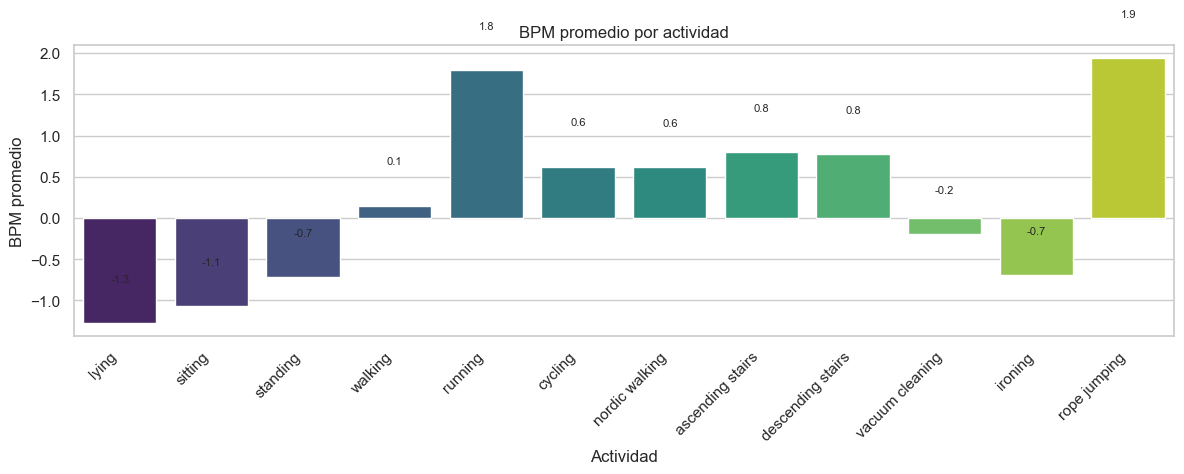

In [27]:
from pathlib import Path
# Intentar usar OUTPUT_PATH si está definido, si no construir la ruta relativa
try:
    csv_path = OUTPUT_PATH / 'pamap2_limpio.csv'
except NameError:
    csv_path = Path('..') / 'data' / 'processed' / 'pamap2_limpio.csv'
print(f'Cargando: {csv_path}')
df_final = pd.read_csv(csv_path)
# Mapear actividad_id -> nombre de actividad
actividad_map = {
    1: 'lying', 2: 'sitting', 3: 'standing', 4: 'walking', 5: 'running', 6: 'cycling',
    7: 'nordic walking', 9: 'watching TV', 10: 'computer work', 11: 'car driving',
    12: 'ascending stairs', 13: 'descending stairs', 16: 'vacuum cleaning',
    17: 'ironing', 18: 'folding laundry', 19: 'house cleaning', 20: 'playing soccer',
    24: 'rope jumping'
}
# Agrupar por actividad_id (manteniendo orden por id) y calcular promedio de frecuencia_cardiaca
grp = (df_final.groupby('actividad_id')['frecuencia_cardiaca']
       .mean().reset_index(name='bpm_promedio'))
grp['actividad'] = grp['actividad_id'].map(actividad_map).fillna(grp['actividad_id'].astype(str))
grp = grp.sort_values('actividad_id')
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,5))
sns.barplot(x='actividad', y='bpm_promedio', data=grp, palette='viridis', order=grp['actividad'])
plt.title('BPM promedio por actividad')
plt.xlabel('Actividad')
plt.ylabel('BPM promedio')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(grp['bpm_promedio']):
    plt.text(i, v + 0.5, f'{v:.1f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## Comparación: giroscopio mano — actividades 6 vs 7
Se calcula la magnitud del giroscopio de la mano (`sqrt(x^2+y^2+z^2)`) y se comparan las medias entre actividad 6 (cycling) y 7 (nordic walking).

Cargando: D:\FACU\5to\Ciencia de datos\pamap2+physical+activity+monitoring\TP_CD\data\processed\pamap2_limpio.csv


C:\Users\Usuario\AppData\Local\Temp\ipykernel_20676\3348565809.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='actividad', y='gyro_mean', data=grp67, palette='magma', order=grp67['actividad'])


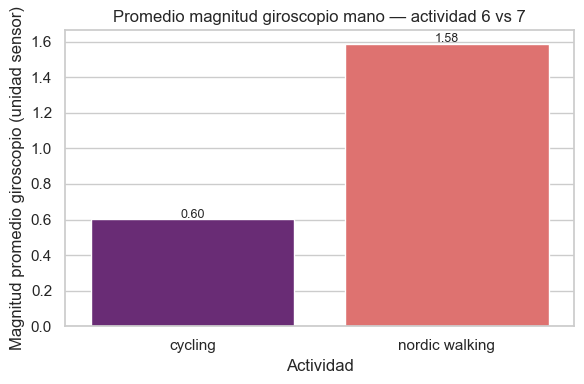

In [28]:
from pathlib import Path
# Cargar CSV procesado (usar OUTPUT_PATH si existe)
try:
    csv_path = OUTPUT_PATH / 'pamap2_limpio.csv'
except NameError:
    csv_path = Path('..') / 'data' / 'processed' / 'pamap2_limpio.csv'
print(f'Cargando: {csv_path}')
df_final = pd.read_csv(csv_path)
# Filtrar actividades 6 y 7 y trabajar sobre una copia para evitar warnings
df_67 = df_final[df_final['actividad_id'].isin([6, 7])].copy()
# Verificar columnas de giroscopio mano
required = ['mano_giro_x', 'mano_giro_y', 'mano_giro_z']
missing = [c for c in required if c not in df_final.columns]
if missing:
    raise KeyError(f'Faltan columnas de giroscopio mano en el CSV: {missing}')
# Calcular magnitud del giroscopio de la mano
df_67['mano_giro_mag'] = (df_67['mano_giro_x']**2 + df_67['mano_giro_y']**2 + df_67['mano_giro_z']**2)**0.5
# Agrupar y calcular promedio por actividad_id
grp67 = df_67.groupby('actividad_id')['mano_giro_mag'].mean().reset_index(name='gyro_mean')
# Mapear ids a nombres (mismo mapping usado previamente)
actividad_map = {
    1: 'lying', 2: 'sitting', 3: 'standing', 4: 'walking', 5: 'running', 6: 'cycling',
    7: 'nordic walking', 9: 'watching TV', 10: 'computer work', 11: 'car driving',
    12: 'ascending stairs', 13: 'descending stairs', 16: 'vacuum cleaning',
    17: 'ironing', 18: 'folding laundry', 19: 'house cleaning', 20: 'playing soccer',
    24: 'rope jumping', 0: 'other'
}
grp67['actividad'] = grp67['actividad_id'].map(actividad_map).fillna(grp67['actividad_id'].astype(str))
grp67 = grp67.sort_values('actividad_id')
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.barplot(x='actividad', y='gyro_mean', data=grp67, palette='magma', order=grp67['actividad'])
plt.title('Promedio magnitud giroscopio mano — actividad 6 vs 7')
plt.xlabel('Actividad')
plt.ylabel('Magnitud promedio giroscopio (unidad sensor)')
for i, v in enumerate(grp67['gyro_mean']):
    plt.text(i, v + 0.01 * v if v!=0 else 0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()